<a href="https://colab.research.google.com/github/raniyaabubacker884/deep-learning/blob/main/day4_task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! unzip "/content/women.zip"


Archive:  /content/women.zip
   creating: women/
   creating: women/angry/
  inflating: women/angry/images (30).jpg  
  inflating: women/angry/images (31).jpg  
  inflating: women/angry/images (32).jpg  
  inflating: women/angry/images (33).jpg  
  inflating: women/angry/images (34).jpg  
  inflating: women/angry/images (35).jpg  
  inflating: women/angry/images (36).jpg  
  inflating: women/angry/images (37).jpg  
  inflating: women/angry/images (38).jpg  
  inflating: women/angry/images (39).jpg  
   creating: women/happy/
  inflating: women/happy/images (1).jpg  
  inflating: women/happy/images (10).jpg  
  inflating: women/happy/images (11).jpg  
  inflating: women/happy/images (12).jpg  
  inflating: women/happy/images (13).jpg  
  inflating: women/happy/images (14).jpg  
  inflating: women/happy/images (15).jpg  
  inflating: women/happy/images (16).jpg  
  inflating: women/happy/images (17).jpg  
  inflating: women/happy/images (18).jpg  
  inflating: women/happy/images (19).jpg

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    "/content/women",
    target_size=(128,128),
    batch_size=8,
    class_mode="categorical",
    subset="training"
)

val_data = train_gen.flow_from_directory(
    "/content/women",
    target_size=(128,128),
    batch_size=8,
    class_mode="categorical",
    subset="validation"
)

Found 40 images belonging to 4 classes.
Found 10 images belonging to 4 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.0750 - loss: 1.7034 - val_accuracy: 0.4000 - val_loss: 1.3590
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.4000 - loss: 1.3485 - val_accuracy: 0.4000 - val_loss: 1.3385
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.4000 - loss: 1.2863 - val_accuracy: 0.4000 - val_loss: 1.3387
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step - accuracy: 0.4000 - loss: 1.3122 - val_accuracy: 0.4000 - val_loss: 1.3310
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.4000 - loss: 1.2914 - val_accuracy: 0.4000 - val_loss: 1.3326
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.4500 - loss: 1.2123 - val_accuracy: 0.4000 - val_loss: 1.3344
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 537ms/step - accuracy: 0.4250 - loss: 1.1680 - val_accuracy: 0.4000 - val_loss: 1.3446
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - accuracy: 0.6000 - loss: 1.0818 - val_accuracy: 0.3000 - val_loss:

In [ ]:
model.save("emotion_model.h5")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/images (10).jpg",
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

labels = list(train_data.class_indices.keys())

print("Predicted Emotion:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Emotion: happy


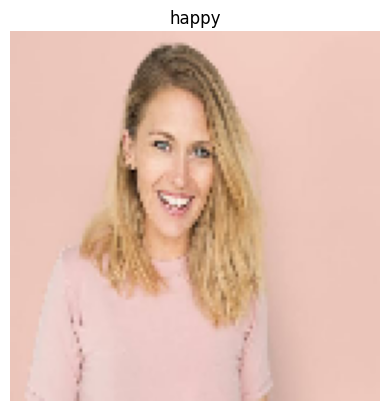

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(labels[predicted_class])
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/images (5).jpg",
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

labels = list(train_data.class_indices.keys())

print("Predicted Emotion:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Emotion: tensed


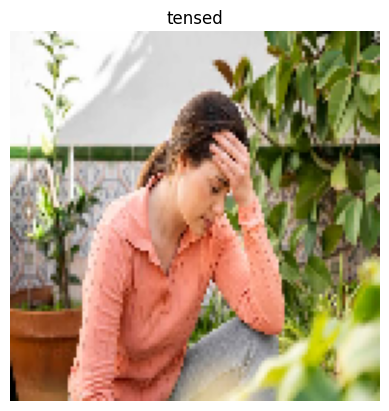

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(labels[predicted_class])
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/images (6).jpg",
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

labels = list(train_data.class_indices.keys())

print("Predicted Emotion:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Emotion: sad


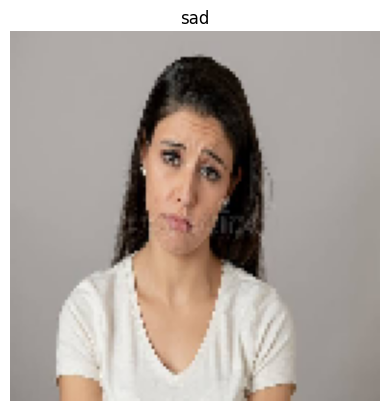

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(labels[predicted_class])
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/images (8).jpg",
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

labels = list(train_data.class_indices.keys())

print("Predicted Emotion:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Emotion: angry


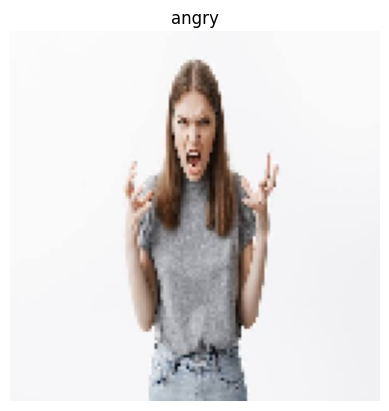

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(labels[predicted_class])
plt.axis("off")
plt.show()